In [1]:
# try to mount google colab
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  cur_dir = "/content/drive/MyDrive/ws/prj/adv_ds_2310/Lab05_Models/ex01_iris_classification/preprocessing"
except:
  cur_dir = "."
  pass
cur_dir = os.path.abspath(cur_dir)
os.chdir(cur_dir)

print(f'cur_dir: {cur_dir} \n --> {os.path.abspath(".")}')

cur_dir: c:\Users\Van Nguyen Duc Thinh\Documents\GitHub\NhomCSTTNT25-26\DuAn\project\eda 
 --> c:\Users\Van Nguyen Duc Thinh\Documents\GitHub\NhomCSTTNT25-26\DuAn\project\eda


#### Khai báo thư viện

In [2]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from scipy.stats import chi2_contingency
import math
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from itertools import combinations

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

In [3]:
exps_dir = "../../exps"
if os.path.exists(exps_dir) == False: # tạo thư mục (nếu chưa có)
  os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/data"
os.makedirs(save_dir, exist_ok=True)

#### Nạp dữ liệu

In [4]:
data_names = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]
data_path = "../../data/banknote_authentication.csv"

df_dataset = pd.read_csv(data_path, names=data_names)

display.display(df_dataset)

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [5]:
print(df_dataset.describe())

          variance     skewness     curtosis      entropy        class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


In [6]:
df_dataset.columns

Index(['variance', 'skewness', 'curtosis', 'entropy', 'class'], dtype='object')

In [7]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [8]:
print(df_dataset.groupby('class') .size())

class
0    762
1    610
dtype: int64


## Làm sạch dữ liệu

#### Kiểm tra dữ liệu NULL

In [9]:
df_dataset.isnull().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

#### Xóa dữ liệu trùng lặp

In [10]:
display.display(df_dataset[df_dataset.duplicated(keep = False)])

,variance,skewness,curtosis,entropy,class
21,0.3292,-4.4552,4.5718,-0.9888,0
41,-0.2062,9.2207,-3.7044,-6.8103,0
45,-0.7869,9.5663,-3.7867,-7.5034,0
47,-0.7869,9.5663,-3.7867,-7.5034,0
107,-1.8584,7.8860,-1.6643,-1.8384,0
119,0.9297,-3.7971,4.6429,-0.2957,0
139,-0.2062,9.2207,-3.7044,-6.8103,0
145,0.5195,-3.2633,3.0895,-0.9849,0
170,0.5706,-0.0248,1.2421,-0.5621,0
190,0.9297,-3.7971,4.6429,-0.2957,0


In [11]:
df_dataset.drop_duplicates(ignore_index=True, inplace=True)
display.display(df_dataset)

,variance,skewness,curtosis,entropy,class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1343,0.40614,1.34920,-1.4501,-0.55949,1
1344,-1.38870,-4.87730,6.4774,0.34179,1
1345,-3.75030,-13.45860,17.5932,-2.77710,1
1346,-3.56370,-8.38270,12.3930,-1.28230,1


## Phân tích khám phá dữ liệu

#### Đếm số biến theo từng loại

In [12]:
object_columns = list(df_dataset.select_dtypes(['object']).columns)
len(object_columns)
numeric_columns=list(df_dataset.select_dtypes('number'))
len(numeric_columns)
print(f"Biến phân loại: {len(object_columns)}, Biến liên tục: {len(numeric_columns)}")

Biến phân loại: 0, Biến liên tục: 5


In [13]:
object_columns

[]

In [14]:
numeric_columns

['variance', 'skewness', 'curtosis', 'entropy', 'class']

In [15]:
df_dataset[numeric_columns].describe()

,variance,skewness,curtosis,entropy,class
count,1348.000000,1348.000000,1348.000000,1348.000000,1348.000000
mean,0.445785,1.909039,1.413578,-1.168712,0.452522
std,2.862906,5.868600,4.328365,2.085877,0.497925
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.786650,-1.627000,-1.545600,-2.393100,0.000000
50%,0.518735,2.334150,0.605495,-0.578890,0.000000
75%,2.853250,6.796025,3.199800,0.403863,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [16]:
numeric_columns.remove('class')
for column in numeric_columns: 
    print("\033[1m","*, Column: ", column,"\033[0m")   
    print('\t',len(df_dataset[column].unique()), "unique values", "\t & \t", 
          df_dataset[column].notnull().sum(), "non-null values\t", 
          round(100* df_dataset[column].notnull().sum()/len(df_dataset[column]),2), 
          "% non-null") 
    if len(df_dataset[column].unique())<=10:
            print('\t',df_dataset[column].unique())


 *, Column:  variance 
	 1338 unique values 	 & 	 1348 non-null values	 100.0 % non-null
 *, Column:  skewness 
	 1256 unique values 	 & 	 1348 non-null values	 100.0 % non-null
 *, Column:  curtosis 
	 1270 unique values 	 & 	 1348 non-null values	 100.0 % non-null
 *, Column:  entropy 
	 1156 unique values 	 & 	 1348 non-null values	 100.0 % non-null


variance


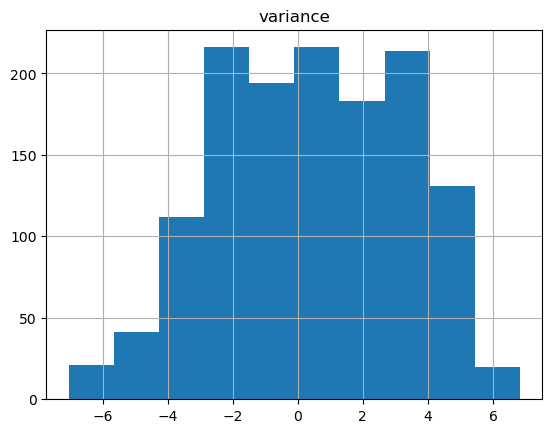

skewness


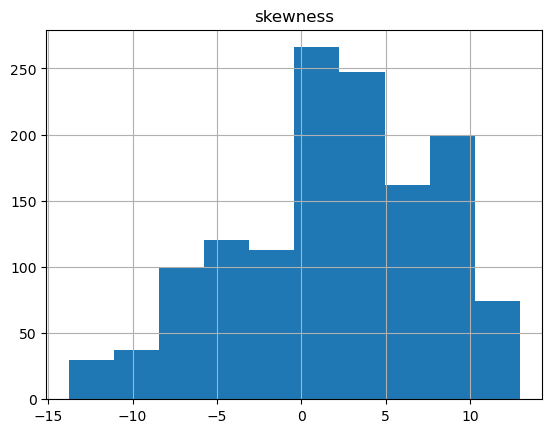

curtosis


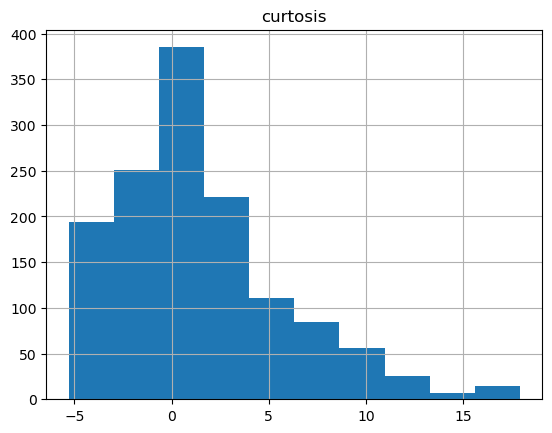

entropy


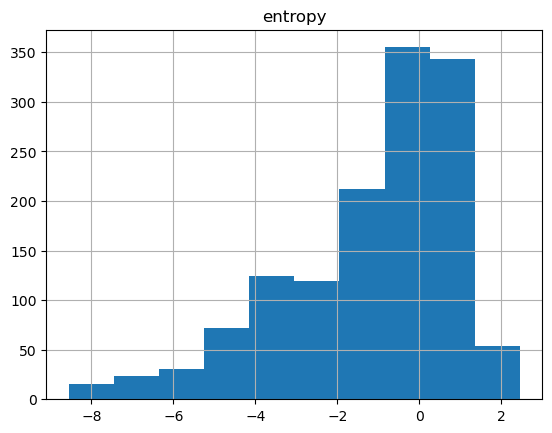

In [17]:
for c in numeric_columns:
    print(c)
    df_dataset.hist(c)
    plt.show()

#### Biểu đồ cột Boxplot

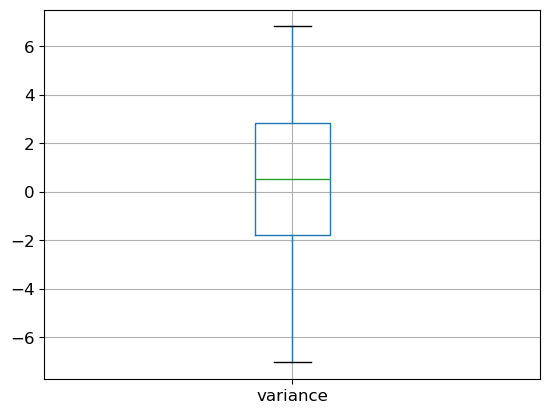

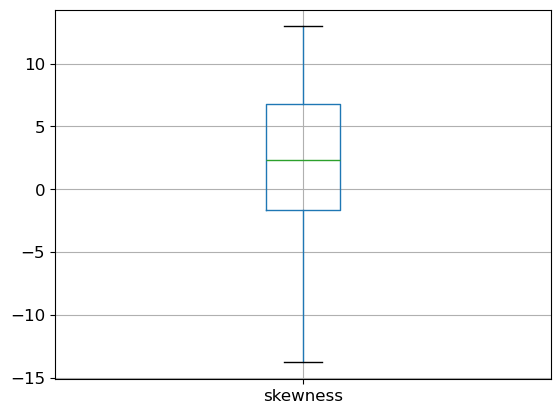

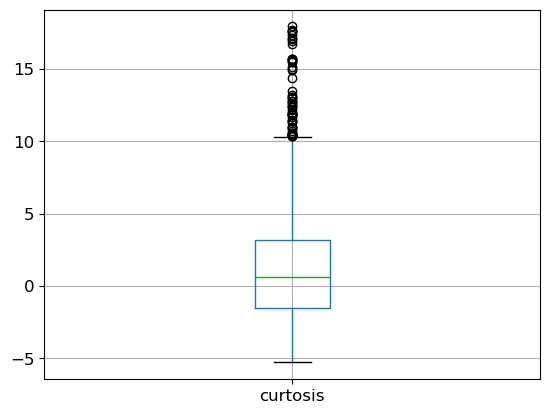

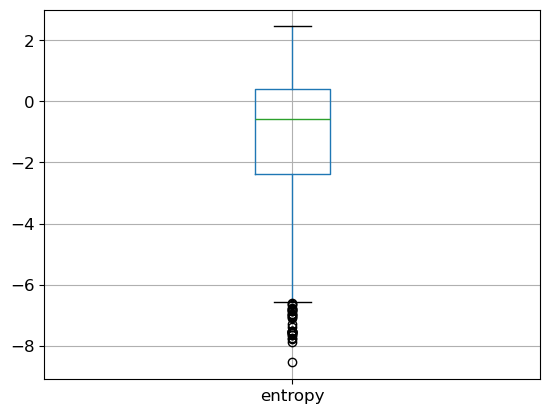

In [18]:
for c in numeric_columns:
    plt.figure()
    df_dataset.boxplot(c, rot=0, grid=True, fontsize=12);
    plt.show()

In [19]:
def check_outliers(name,outliers_list):
    we=df_dataset[name].values
    Q1=np.quantile(we,0.25)
    Q3=np.quantile(we,0.75)
    IQR=Q3-Q1
    print("Q1: ",Q1,"Q3: ",Q3,"IQR:",IQR)
    outliers=np.unique(we[[(n<Q1-1.5*IQR)|(n>Q3+1.5*IQR) for n in we]])
    indexes=[we.tolist().index(i) for i in outliers]
    if len(indexes)>0:
        outliers_list.append(name)
    print("Indexes of outliers: ", indexes)
    print("Number of outliers: ", len(indexes))
    print("Outlier values", we[indexes])
    print("-----")

In [20]:
outliers_list=[]
for col in numeric_columns:
    check_outliers(col,outliers_list)
np.savez(f'{exps_dir}/data/outliers.npz', outliers = outliers_list)

print(outliers_list)

Q1:  -1.78665 Q3:  2.85325 IQR: 4.6399
Indexes of outliers:  []
Number of outliers:  0
Outlier values []
-----
Q1:  -1.627 Q3:  6.796025 IQR: 8.423025
Indexes of outliers:  []
Number of outliers:  0
Outlier values []
-----
Q1:  -1.5456 Q3:  3.1998 IQR: 4.7454
Indexes of outliers:  [1108, 1280, 853, 1036, 1219, 925, 1340, 1041, 1157, 974, 791, 1341, 914, 1097, 792, 1158, 975, 919, 1102, 1035, 913, 1285, 1096, 878, 1000, 858, 1224, 980, 1346, 797, 1163, 1061, 817, 1122, 939, 1244, 756, 1305, 924, 985, 802, 1290, 1229, 863, 1107, 1168, 1046, 741, 1284, 979, 1223, 1162, 857, 1040, 1345, 1101, 796, 918]
Number of outliers:  58
Outlier values [10.3315 10.3332 10.3846 10.4052 10.4266 10.4403 10.4849 10.5234 10.5251
 10.5405 10.7402 10.8867 10.939  10.969  10.9818 11.244  11.388  11.3897
 11.4419 11.6433 11.8318 11.8387 11.8678 11.9149 11.9552 11.9655 12.1291
 12.363  12.393  12.4547 12.555  12.6689 12.7957 12.9817 13.0545 13.0597
 13.1779 13.4727 14.3689 14.8881 14.9704 15.1606 15.4417 15.557

### Kết luận:
- Các cột không chứa quá nhiều giá trị ngoại lệ. Ở bước tiền xử lý dữ liệu, chúng ta có thể xóa ngoại lệ để sử dụng **MinMaxScaler** để tiến hành chuẩn hóa dữ liệu số ( vì nhạy cảm với giá trị ngoại lệ).

#### MinMaxScaler

In [21]:
corrle=df_dataset[numeric_columns].corr()
corrle

,variance,skewness,curtosis,entropy
variance,1.000000,0.272863,-0.387171,0.273993
skewness,0.272863,1.000000,-0.785376,-0.520293
curtosis,-0.387171,-0.785376,1.000000,0.311379
entropy,0.273993,-0.520293,0.311379,1.000000


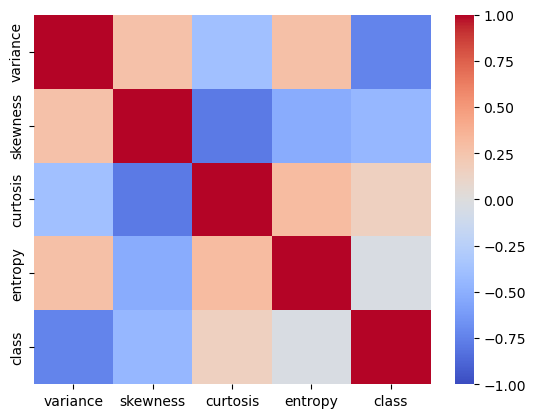

In [22]:
sns.heatmap(df_dataset.corr(),vmin=-1,vmax=1, annot=False, fmt=".2f",cmap='coolwarm')
plt.show()

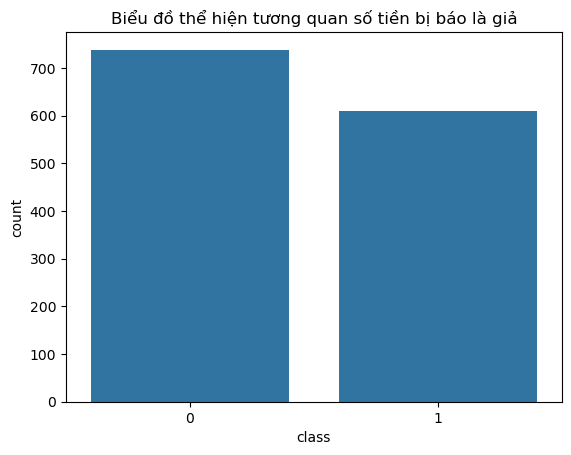

In [23]:
sns.countplot(x='class',data=df_dataset)
plt.title("Biểu đồ thể hiện tương quan số tiền bị báo là giả")
plt.show()

### Kết luận:
- Tỉ lệ số tiền được cho là giả quá lớn, gần bằng số lượng tiền thật. Đây có thể ảnh hưởng rất lớn tới mô hình dự đoán khi biến mục tiêu xuất hiện tình trạng mất cân bằng **(imbalanced variable).**

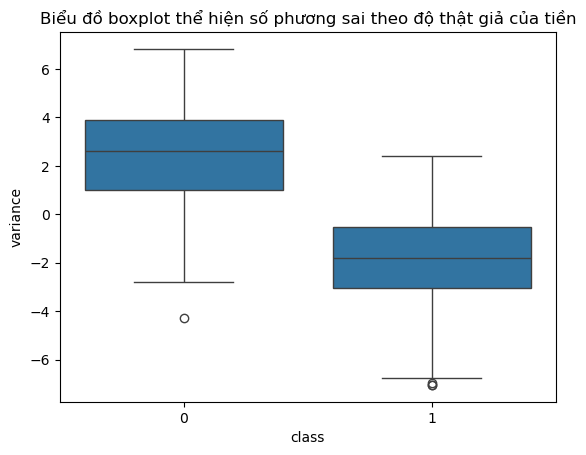

In [24]:
sns.boxplot(data=df_dataset, x="class", y="variance")
plt.title('Biểu đồ boxplot thể hiện số phương sai theo độ thật giả của tiền')
plt.show()

#### Biểu đồ Histogram

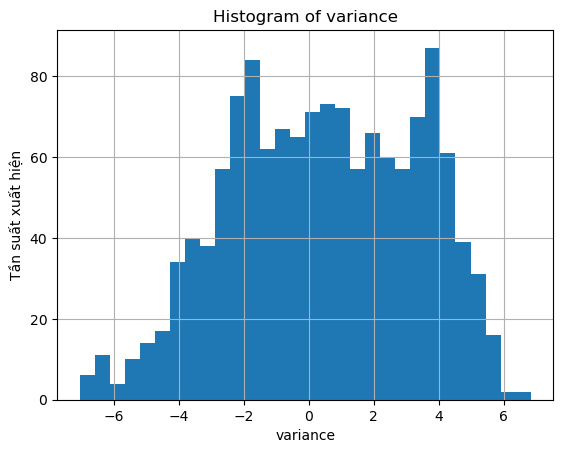

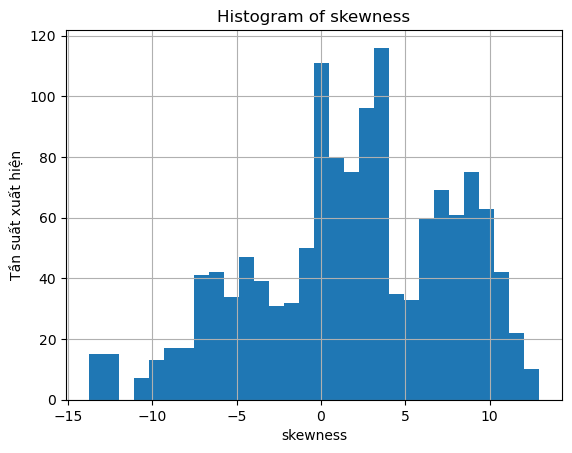

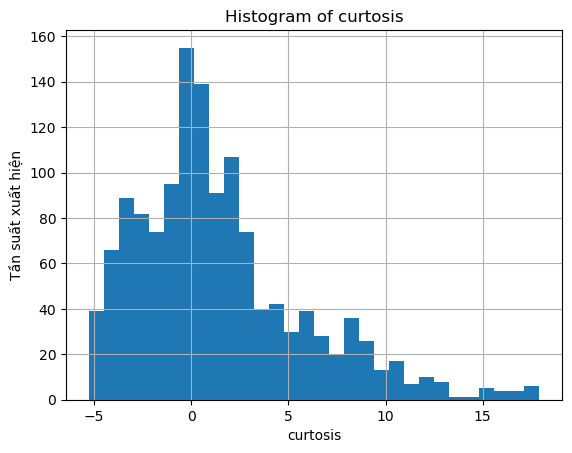

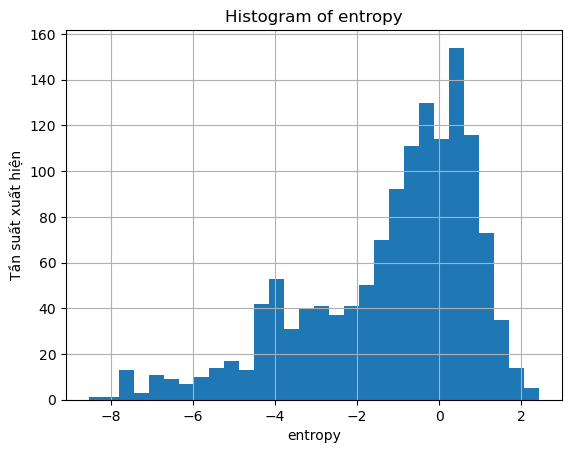

In [25]:
features = ["variance", "skewness", "curtosis", "entropy"]

for col in features:
    plt.figure()
    plt.hist(df_dataset[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất xuất hiện")
    plt.grid(True)
    plt.show()

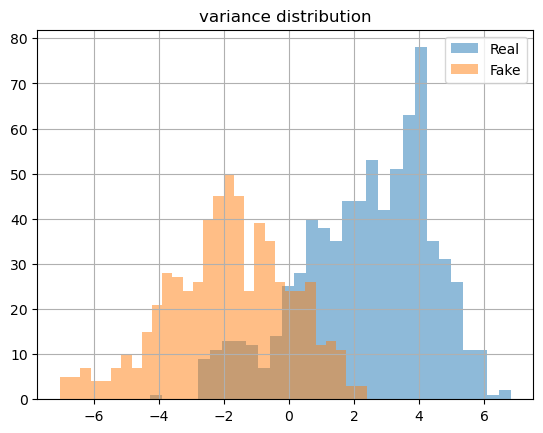

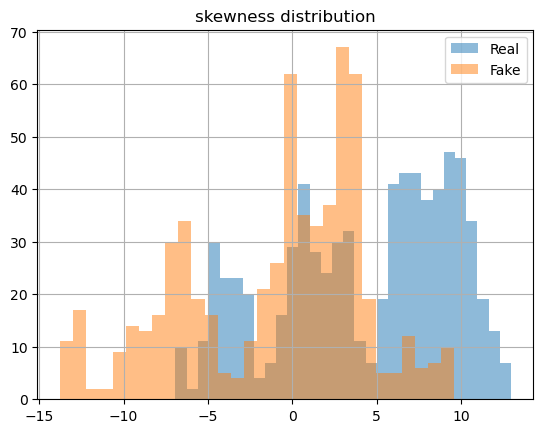

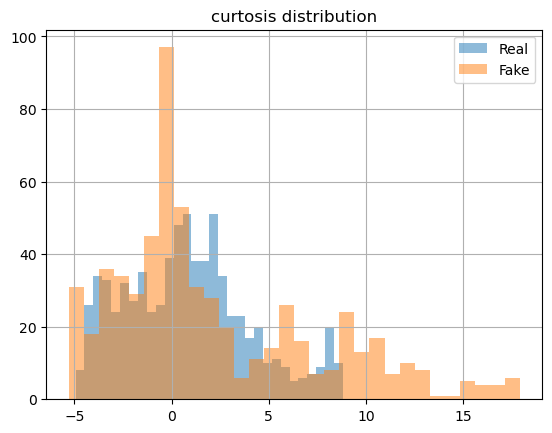

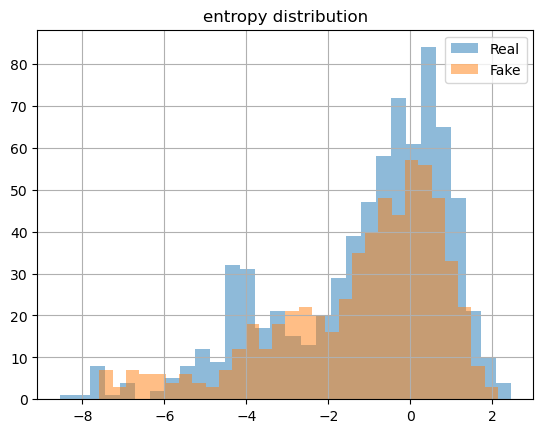

In [26]:
real = df_dataset[df_dataset["class"] == 0]
fake = df_dataset[df_dataset["class"] == 1]
for col in features:
    plt.figure()
    plt.hist(real[col], bins=30, alpha=0.5, label="Real")
    plt.hist(fake[col], bins=30, alpha=0.5, label="Fake")
    plt.title(f"{col} distribution")
    plt.legend()
    plt.grid(True)
    plt.show()

#### Ma trận tương quan

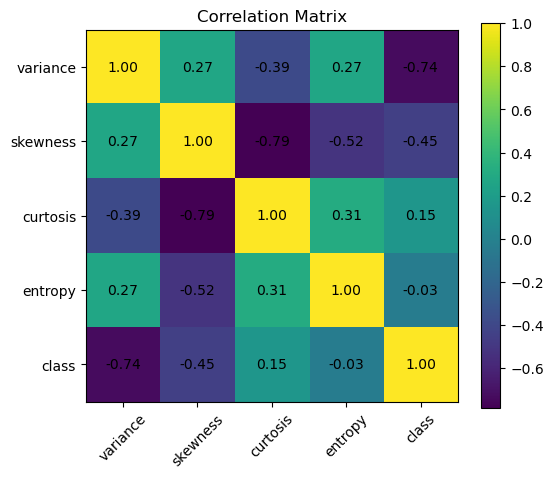

In [27]:
corr = df_dataset.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

ticks = np.arange(len(corr.columns))
plt.xticks(ticks, corr.columns, rotation=45)
plt.yticks(ticks, corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Matrix")
plt.show()

#### Variance vs Class

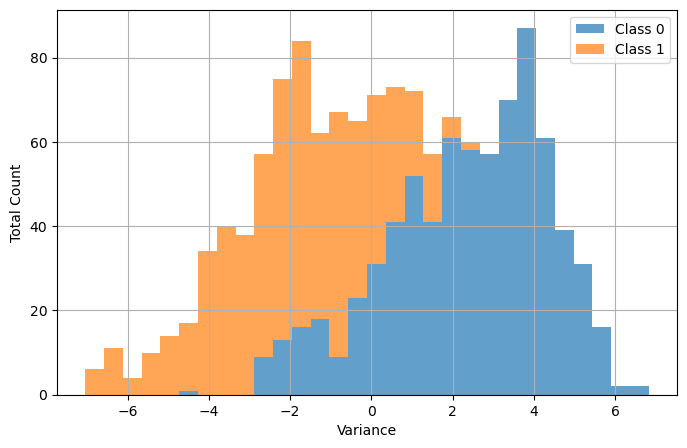

In [28]:
real = df_dataset[df_dataset["class"] == 0]["variance"]
fake = df_dataset[df_dataset["class"] == 1]["variance"]

plt.figure(figsize=(8,5))

plt.hist(
    [real, fake],
    bins=30,
    stacked=True,
    label=["Class 0", "Class 1"],
    alpha=0.7
)

plt.xlabel("Variance")
plt.ylabel("Total Count")
plt.legend()
plt.grid(True)

plt.show()

##### Nhận xét:
+ Variance càng cao -> tiền thật
+ Variance càng thấp -> tiền giả

#### Skewness vs Class

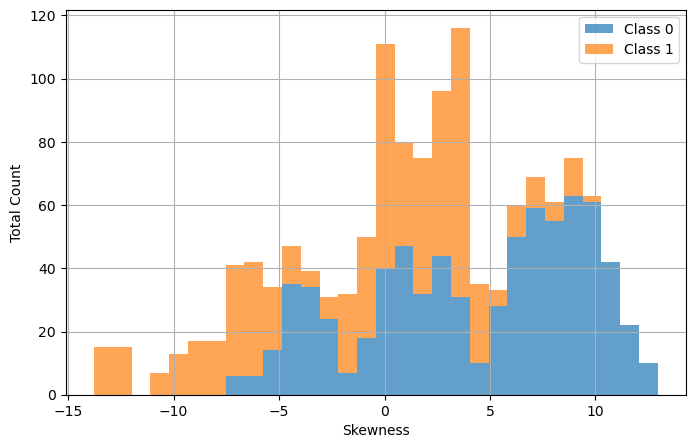

In [29]:
real = df_dataset[df_dataset["class"] == 0]["skewness"]
fake = df_dataset[df_dataset["class"] == 1]["skewness"]

plt.figure(figsize=(8,5))

plt.hist(
    [real, fake],
    bins=30,
    stacked=True,
    label=["Class 0", "Class 1"],
    alpha=0.7
)

plt.xlabel("Skewness")
plt.ylabel("Total Count")
plt.legend()
plt.grid(True)

plt.show()

##### Nhận xét:
+ Skewness càng cao -> tiền thật
+ Skewness càng thấp -> tiền giả
+ Phải từ số liệu 10 trở đi mới hạn chế được số tiền giả

#### Đồ thị 1 biến và 2 biến

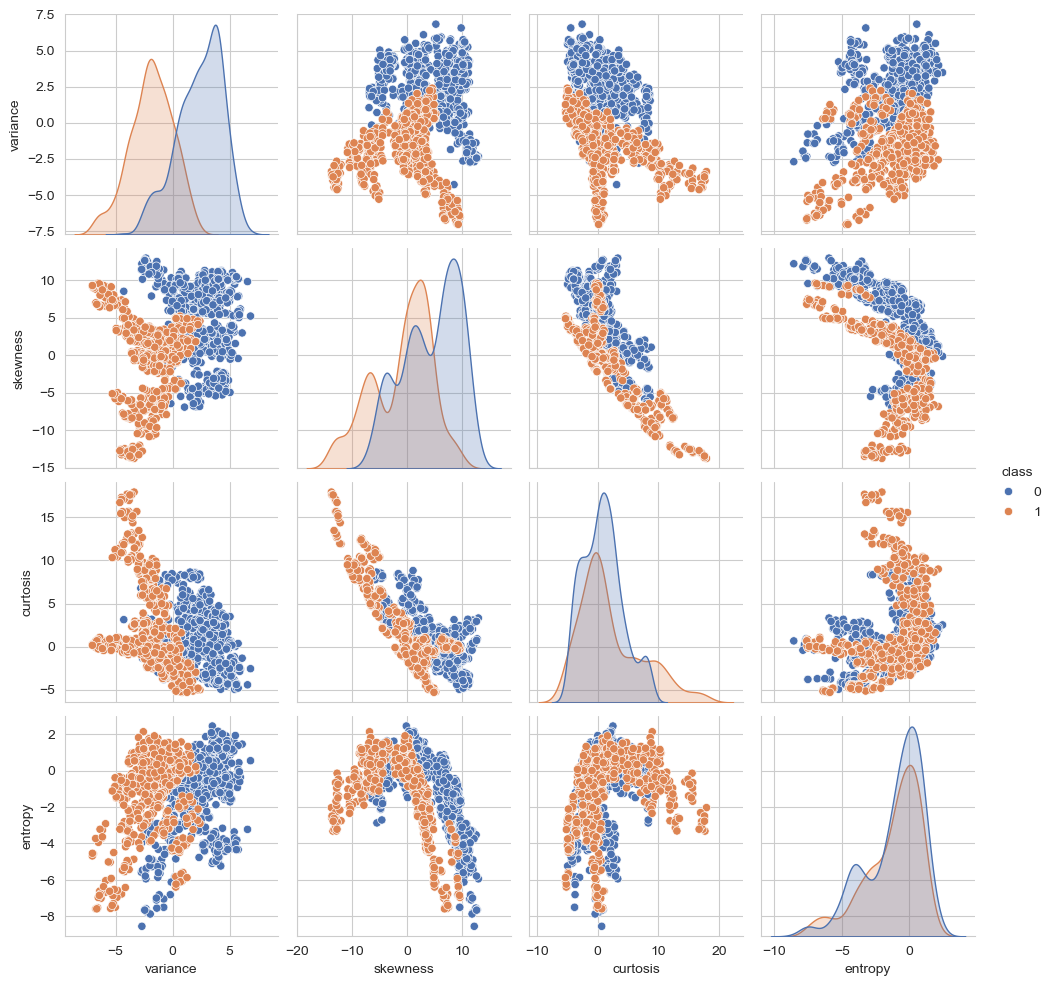

In [30]:
sns.set_style("whitegrid")

sns.pairplot(
    df_dataset,
    hue="class",
    palette="deep",
    diag_kind="kde"
)

plt.show()

#### Hình hộp plot 3 biến

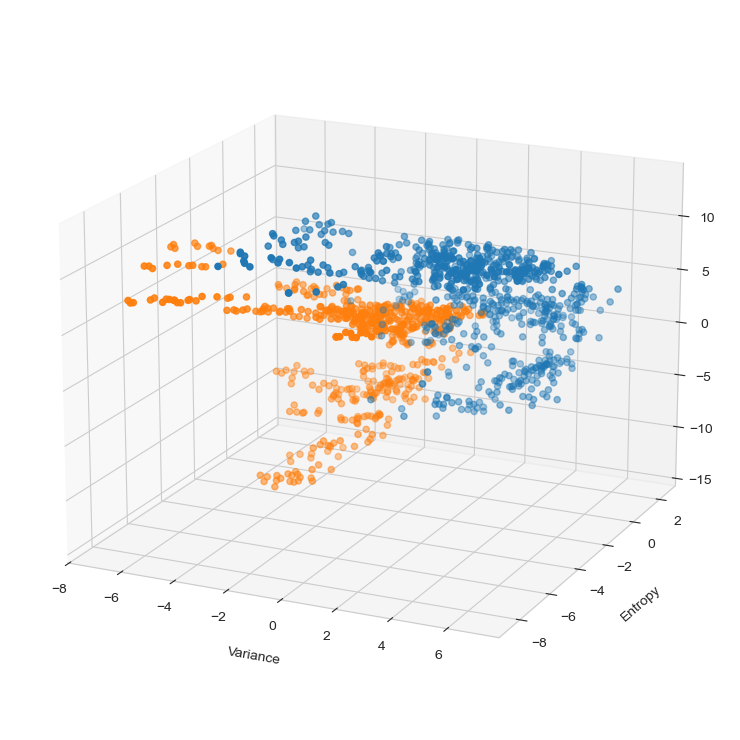

In [31]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

real = df_dataset[df_dataset["class"] == 0]
fake = df_dataset[df_dataset["class"] == 1]

ax.scatter(real["variance"], real["entropy"], real["skewness"])
ax.scatter(fake["variance"], fake["entropy"], fake["skewness"])

ax.set_xlabel("Variance", labelpad=10)
ax.set_ylabel("Entropy", labelpad=10)
ax.set_zlabel("Skewness", labelpad=20)

# góc nhìn giống hình bạn
ax.view_init(elev=18, azim=-65)

# tránh bị cắt chữ
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)
plt.show()

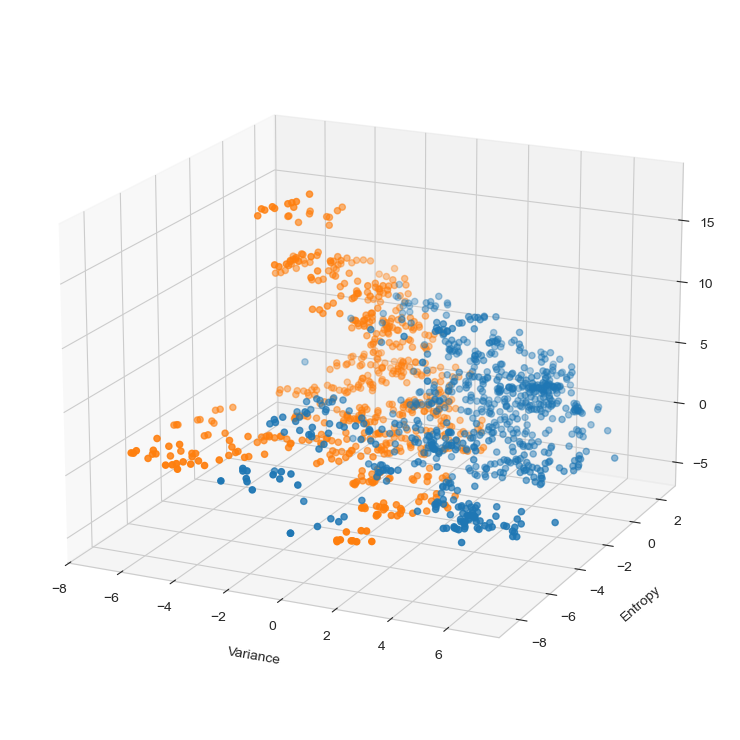

In [32]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

real = df_dataset[df_dataset["class"] == 0]
fake = df_dataset[df_dataset["class"] == 1]

ax.scatter(real["variance"], real["entropy"], real["curtosis"])
ax.scatter(fake["variance"], fake["entropy"], fake["curtosis"])

ax.set_xlabel("Variance", labelpad=10)
ax.set_ylabel("Entropy", labelpad=10)
ax.set_zlabel("Curtosis", labelpad=20)

# góc nhìn giống hình bạn
ax.view_init(elev=18, azim=-65)

# tránh bị cắt chữ
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)
plt.show()

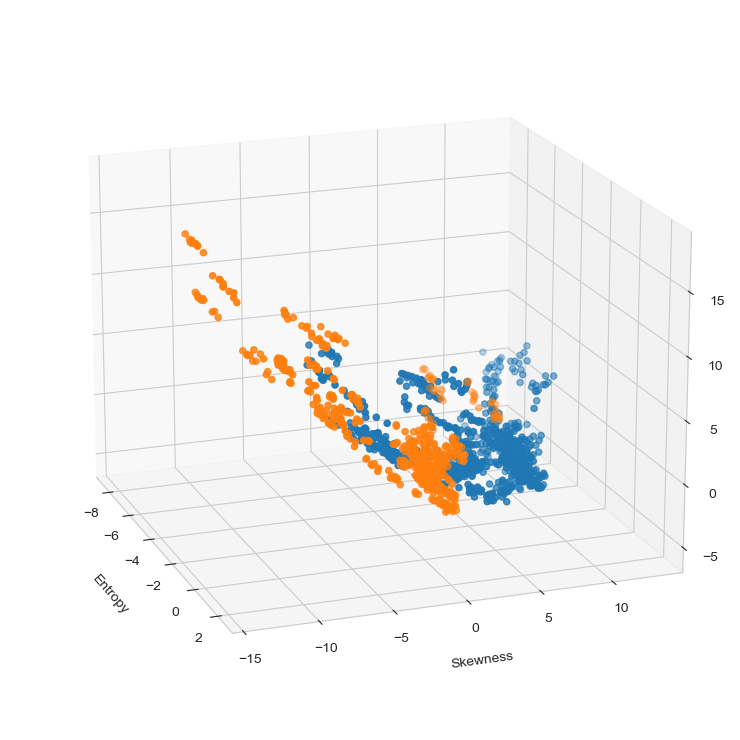

In [33]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

real = df_dataset[df_dataset["class"] == 0]
fake = df_dataset[df_dataset["class"] == 1]

ax.scatter(real["entropy"], real["skewness"], real["curtosis"])
ax.scatter(fake["entropy"], fake["skewness"], fake["curtosis"])

ax.set_xlabel("Entropy", labelpad=10)
ax.set_ylabel("Skewness", labelpad=10)
ax.set_zlabel("Curtosis", labelpad=20)

# góc nhìn giống hình bạn
ax.view_init(elev=18, azim=-20)

# tránh bị cắt chữ
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)
plt.show()

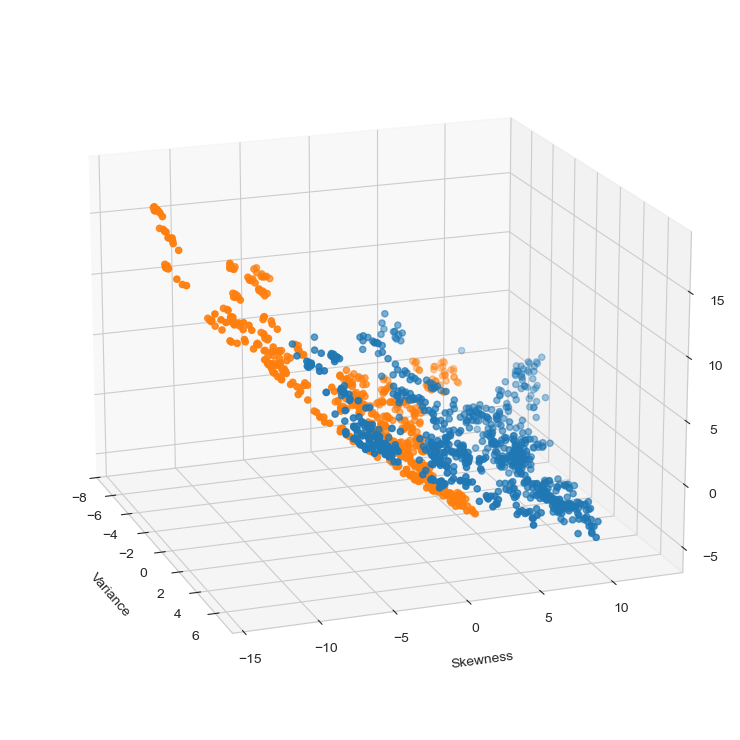

In [34]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

real = df_dataset[df_dataset["class"] == 0]
fake = df_dataset[df_dataset["class"] == 1]

ax.scatter(real["variance"], real["skewness"], real["curtosis"])
ax.scatter(fake["variance"], fake["skewness"], fake["curtosis"])

ax.set_xlabel("Variance", labelpad=10)
ax.set_ylabel("Skewness", labelpad=10)
ax.set_zlabel("Curtosis", labelpad=20)

# góc nhìn giống hình bạn
ax.view_init(elev=18, azim=-20)

# tránh bị cắt chữ
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95)
plt.show()

In [35]:
features = ["variance", "skewness", "curtosis", "entropy"]
pairs = list(combinations(features, 2))

results = []

for f1, f2 in pairs:
    
    X = df_dataset[[f1, f2]]
    y = df_dataset["class"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    results.append({
        "Metric": f"{f1[:1]}-{f2[:1]}",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

df_pair_metrics = pd.DataFrame(results)
df_pair_metrics.set_index("Metric", inplace=True)

df_pair_metrics = df_pair_metrics.T.round(2)
df_pair_metrics

Metric,v-s,v-c,v-e,s-c,s-e,c-e
Accuracy,0.90,0.88,0.90,0.76,0.74,0.61
Precision,0.87,0.83,0.88,0.72,0.75,0.64
Recall,0.91,0.93,0.91,0.75,0.64,0.33
F1,0.89,0.87,0.89,0.74,0.69,0.44


In [39]:
df_dataset.to_excel(f'{exps_dir}/data/data_EDA.xlsx', index=None)
df_dataset["class"] = df_dataset["class"].astype("category")

object_columns = list(df_dataset.select_dtypes(['object']).columns)
df_dataset[object_columns]=df_dataset[object_columns].astype('category')
category_columns = list(df_dataset.select_dtypes(['category']).columns)

numeric_columns = list(df_dataset.select_dtypes(include=['int64','float64']).columns)

np.savez(f'{exps_dir}/data/columns_dtype.npz', category_columns = category_columns, numeric_columns = numeric_columns)

## Kết thúc

In [ ]:
df = df_dataset.copy()
X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 70% train, 30% test
    random_state=42,
    stratify=y          # giữ tỷ lệ class
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (943, 4)
Test size: (405, 4)


In [ ]:
scaler = StandardScaler()

# fit trên train
X_train_scaled = scaler.fit_transform(X_train)

# transform test
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (943, 4)
Scaled test shape: (405, 4)


In [ ]:
models = {
    "kNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "MLP": MLPClassifier(max_iter=1000, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# train tất cả models
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained")

kNN trained
Naive Bayes trained
SVM trained
Decision Tree trained
Random Forest trained
AdaBoost trained
Gradient Boosting trained
LDA trained
MLP trained
Logistic Regression trained


In [ ]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        round(acc, 2),
        round(prec, 2),
        round(rec, 2),
        round(f1, 2),
        round(auc, 2)
    ])

# tạo bảng kết quả
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC"]
)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,kNN,1.00,0.99,1.00,1.00,1.00
2,SVM,1.00,0.99,1.00,1.00,1.00
4,Random Forest,1.00,0.99,1.00,1.00,1.00
6,Gradient Boosting,1.00,1.00,1.00,1.00,1.00
3,Decision Tree,0.99,0.99,0.99,0.99,0.99
5,AdaBoost,0.99,0.98,1.00,0.99,1.00
7,LDA,0.99,0.97,1.00,0.99,1.00
8,MLP,0.99,0.97,1.00,0.99,1.00
9,Logistic Regression,0.99,0.97,1.00,0.99,1.00
1,Naive Bayes,0.87,0.85,0.86,0.86,0.95


In [ ]:
param_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"]
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_
print("Best SVM:", grid_svm.best_params_)

Best SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
print("Best RF:", grid_rf.best_params_)

Best RF: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
param_knn = {
    "n_neighbors": [3,5,7,9],
    "weights": ["uniform", "distance"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_knn,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
print("Best kNN:", grid_knn.best_params_)

Best kNN: {'n_neighbors': 3, 'weights': 'distance'}


In [ ]:
param_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_gb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train_scaled, y_train)

best_gb = grid_gb.best_estimator_
print("Best GB:", grid_gb.best_params_)

Best GB: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [ ]:
param_lr = {
    "C": [0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
print("Best LR:", grid_lr.best_params_)

Best LR: {'C': 1, 'solver': 'lbfgs'}


In [ ]:
tuned_models = {
    "SVM tuned": best_svm,
    "RF tuned": best_rf,
    "kNN tuned": best_knn,
    "GB tuned": best_gb,
    "LR tuned": best_lr
}

In [ ]:
tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    tuned_results.append([
        name,
        round(acc, 2),
        round(prec, 2),
        round(rec, 2),
        round(f1, 2),
        round(auc, 2)
    ])

tuned_results_df = pd.DataFrame(
    tuned_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "AUC"]
)

tuned_results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,SVM tuned,1.00,1.00,1.0,1.00,1.0
1,RF tuned,1.00,0.99,1.0,1.00,1.0
2,kNN tuned,1.00,0.99,1.0,1.00,1.0
3,GB tuned,1.00,1.00,1.0,1.00,1.0
4,LR tuned,0.99,0.97,1.0,0.99,1.0


In [ ]:
comparison_df = pd.concat([results_df, tuned_results_df])
comparison_df

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,kNN,1.00,0.99,1.00,1.00,1.00
1,Naive Bayes,0.87,0.85,0.86,0.86,0.95
2,SVM,1.00,0.99,1.00,1.00,1.00
3,Decision Tree,0.99,0.99,0.99,0.99,0.99
4,Random Forest,1.00,0.99,1.00,1.00,1.00
5,AdaBoost,0.99,0.98,1.00,0.99,1.00
6,Gradient Boosting,1.00,1.00,1.00,1.00,1.00
7,LDA,0.99,0.97,1.00,0.99,1.00
8,MLP,0.99,0.97,1.00,0.99,1.00
9,Logistic Regression,0.99,0.97,1.00,0.99,1.00


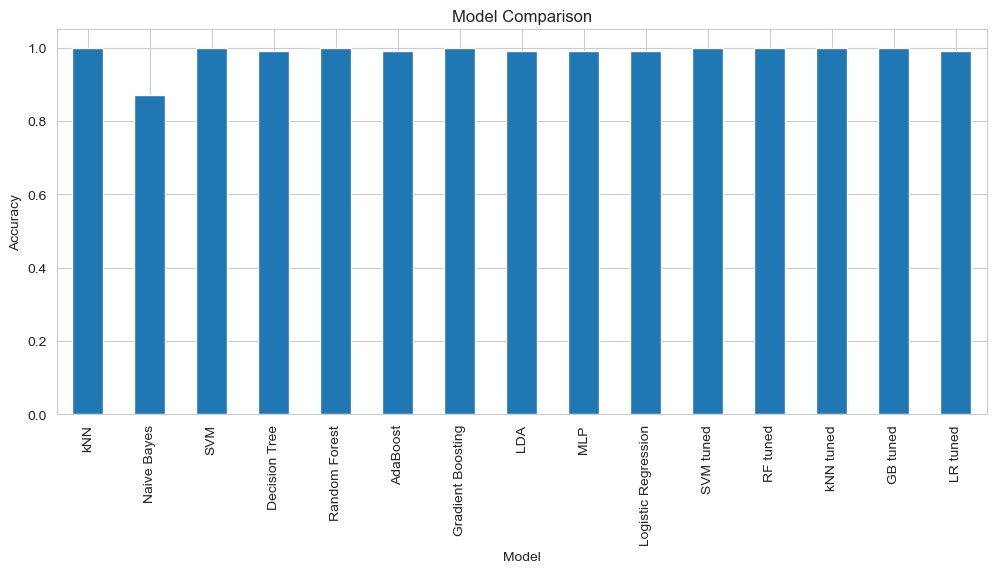

In [ ]:
comparison_df.set_index("Model")["Accuracy"].plot(kind="bar", figsize=(12,5))
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()